In [34]:
from datetime import datetime, timedelta
import datetime

from jqdata import *
from jqfactor import *

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import math
import statsmodels.api as sm
from statsmodels import regression
from scipy.optimize import minimize
from scipy import stats
import scipy.stats as st

import warnings  
warnings.filterwarnings('ignore') 

mpl.rcParams['font.sans-serif'] = ['SimHei']    
mpl.rcParams['axes.unicode_minus'] = False     
sns.set_style({'font.sans-serif':['simhei', 'Arial']})
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
plt.style.use('ggplot')

# 1.函数构造

## 1.1获取指定频率交易日数据

In [35]:
#获取交易日列表，返回DatetimeIndex对象
def get_tradeday_list(start,end,frequency=None,count=None):
    if count != None:
        df = get_price('000001.XSHG',end_date=end,count=count)#有计数n，返回后n天
    else:
        df = get_price('000001.XSHG',start_date=start,end_date=end)#否则返回始末日期之间
    if frequency == None or frequency =='D':
        return df.index
    else:
        df['year-month'] = [str(i)[0:7] for i in df.index]#返回年月
        if frequency == 'M':
            return df.drop_duplicates('year-month').index#根据年月去重
        elif frequency == 'Q':
            df['month'] = [str(i)[5:7] for i in df.index]
            df = df[(df['month']=='01') | (df['month']=='04')\
                    | (df['month']=='07') | (df['month']=='10') ]#返回1、4、7、10月
            return df.drop_duplicates('year-month').index#去重
        elif frequency =='H-Y':
            df['month'] = [str(i)[5:7] for i in df.index]
            df = df[(df['month']=='01') | (df['month']=='06')]#返回1、6月
            return df.drop_duplicates('year-month').index#去重

## 1.2 筛选股票池

In [36]:
#返回指定交易日下一个交易日
def ShiftTradingDay(date,shift):
    # 获取所有的交易日(从2005年开始),返回一个包含所有交易日的 list,元素值为 datetime.date 类型.
    tradingday = get_all_trade_days()
    # 得到date之后shift天那一天在列表中的行标号 返回一个数
    date = datetime.date(int(str(date)[:4]),int(str(date)[5:7]),int(str(date)[8:10]))
    shiftday_index = list(tradingday).index(date)+shift
    # 根据行号返回该日日期 为datetime.date类型
    return tradingday[shiftday_index] 

#进行新股、St股过滤，返回筛选后的股票
#！！！不能过滤停牌股票
def filter_stock(stockList,date,days=21*3,limit=0):
    #去除上市距beginDate不足3个月的股票
    def delect_stop(stocks,beginDate,n=days):
        stockList=[]
        beginDate = datetime.datetime.strptime(beginDate, "%Y-%m-%d")
        for stock in stocks:
            start_date=get_security_info(stock).start_date
            if start_date<(beginDate-datetime.timedelta(days=n)).date():
                stockList.append(stock)
        return stockList
    
    #剔除ST股
    st_data=get_extras('is_st',stockList, count = 1,end_date=date)
    stockList = [stock for stock in stockList if not st_data[stock][0]]
    
    # 判断当天是否全天停牌
    is_susp = get_price(stockList,end_date=date, count=1,fields='paused'\
                        ,panel=False).set_index('code')[['paused']]
    stockList = is_susp[is_susp==1].index.tolist()
    
    #新股及退市股票
    stockList=delect_stop(stockList,date)
    
    #剔除开盘涨跌停股票
    if limit == 1:
        #如果需要收盘涨跌停可以改字段即可
        df = get_price(stockList,end_date=date,\
                       fields=['open','high_limit','low_limit'],count=1).iloc[:,0,:]
        df['h_limit']=(df['open']==df['high_limit'])
        df['l_limit']=(df['open']==df['low_limit'])
        stockList = [df.index[i] for i in range(len(df)) if not\
                     (df.h_limit[i] or df.l_limit[i])] #过滤涨跌停股票
    return stockList

## 1.3 行业标记

In [37]:
#为股票池添加行业标记,return df格式 ,为中性化函数的子函数   
def get_industry_exposure1(stock_list,date):
    stock_list = list(stock_list)
    df = pd.DataFrame(index=get_industries(name='sw_l1').index, columns=stock_list)
    s = get_industry(security=stock_list, date=date)
    ind_dict = {}#创建一个每个股票所在行业的字典（'sw_l1'标准）
    for idx,stock in enumerate(stock_list):
        #自从2019年后存在找不到'sw_l1'的股票情况
        if 'sw_l1' in s[stock].keys() :
            ind_dict[stock] = s[stock]['sw_l1']['industry_code']
        else:
            # 以相邻股票行业作为自己的行业
            ind_dict[stock] = ind_dict[stock_list[idx-1]]
    
    for stock in stock_list:
        df.loc[ind_dict[stock],stock] = 1

    return df.fillna(0)

## 1.4IC统计相关函数

In [38]:
def dict_to_df(dct,index,name=None):
    df = pd.DataFrame(dct,index=index).T
    df.index = pd.to_datetime(df.index)
    if name:
        df.index.name = name
    return df

def evaluation(ic_df, beta_df, t_df):
    '''
    ic_df: df
    beta_df: df
    t_df: df
    return:
    '''
    eval_dict = {}
    # ----ic----
    ic_mean = []
    ic_002 = []
    ir = []
    # ---beta----
    beta_mean = []
    t_test = []
    p_value = []
    # ----t----
    t_mean = []
    t_2 = []

    for factor in ic_df.columns:
        # 计算ic均值
        mean_temp = np.around(ic_df[factor].mean(), 4)
        # ic绝对值大于0.02的比例
        ratio_002 = np.around(np.sum(ic_df[factor].abs() > 0.02)\
                              / len(ic_df.index) * 100, 2)
        # IR
        IR = np.around(mean_temp / ic_df[factor].std(), 4)

        # 添加进列表
        ic_mean.append(mean_temp)
        ic_002.append(str(ratio_002) + '%')
        ir.append(IR)
    print("ic表处理完毕!")
    
    for factor in beta_df.columns:
        # 因子收益率均值
        mean_temp = np.around(beta_df[factor].mean(), 4)
        # t检验
        t, p = np.around(st.ttest_1samp((beta_df[factor]), 0), 4)
        # 添加进列表
        beta_mean.append(mean_temp)
        t_test.append(t)
        p_value.append(p)
    print("beta表处理完毕!")
    
    for factor in t_df.columns:
        # t值绝对值的均值
        mean_temp = np.around(t_df[factor].abs().mean(), 4)
        # 大于2的占比
        ratio_2 = np.around(np.sum(t_df[factor].abs() > 2) / len(t_df.index) * 100, 2)

        # 添加列表
        t_mean.append(mean_temp)
        t_2.append(str(ratio_2) + '%')
    print("t值表处理完毕!")
    
    # 添加进字典
    eval_dict['IC均值'] = ic_mean
    eval_dict['|IC|>0.02'] = ic_002
    eval_dict['IR'] = ir
    eval_dict['因子收益率均值'] = beta_mean
    eval_dict['因子收益率t检验'] = t_test
    eval_dict['p值'] = p_value
    eval_dict['|t|均值'] = t_mean
    eval_dict['|t|大于2的占比'] = t_2
    
    # 字典转df
    eval_df = pd.DataFrame(eval_dict,index=t_df.columns)
    eval_df['score'] = eval_df.apply(score,axis=1)
    eval_df = eval_df.sort_values('score',ascending=False)#降序
    
    return eval_df

def score(series):
    """
    打分函数
    """
    score = 0
    if abs(series['IC均值'])>0.02:
        score +=1
    if abs(series['因子收益率t检验'])> 1.8:#存在问题
        score +=1
    if abs(series['IR'])>0.3:
        score +=1
    if series['|t|均值']>2:
        score +=1
    return score

## 1.5相关性画图函数

In [39]:
def plot_heat(ic_df,eval_df):
    # 截取表现好的因子
    eval_df = eval_df[eval_df['score']>=2]
    ic_df = ic_df.loc[:,eval_df.index]
    corr = np.around(ic_df.corr('spearman'),2)
    fig,ax = plt.subplots(figsize=(20,10))
    sns.heatmap(corr.abs(),annot=True,cmap='RdPu',ax=ax)
    return corr

# 2 数据获取

## 2.1初始设置

In [40]:
#设置统计数据区间
index = '000985.XSHG' #设置股票池，和对比基准，这里是中证500
#stocks_list=list(get_all_securities(['stock']).index)

#设置统计起止日期
date_start = '2023-07-08'
date_end   = '2023-07-14'

#设置调仓频率
trade_freq = 'day' #month每个自然月；day每个交易日；输入任意数字如 5，则为5日调仓 

#获取调仓时间列表
if trade_freq == 'month':  
    #获取交易日列表，每月首个交易日
    date_list = get_tradeday_list(start=date_start,end=date_end,frequency='M',count=None) #自然月的第一天
elif trade_freq == 'day': 
    date_list = get_tradeday_list(start=date_start,end=date_end,count=None)#获取回测日期间的所有交易日
else:
    date_day_list = get_tradeday_list(start=date_start,end=date_end,count=None)#获取回测日期间的所有交易日
    date_list = [date_day_list[i] for i in range(len(date_day_list)) if i%int(trade_freq) == 0]


In [41]:
date_list #每月首个交易日

DatetimeIndex(['2023-07-10', '2023-07-11', '2023-07-12', '2023-07-13', '2023-07-14'], dtype='datetime64[ns]', freq=None)

## 2.2 获取风格因子

In [42]:
#通过聚宽因子获取barra风险因子值进行记录
factor_name = ['size','beta','momentum','residual_volatility','non_linear_size',\
               'book_to_price_ratio','liquidity','earnings_yield',\
               'growth','leverage']
def get_barra_factor(stock_list,date): #返回df对象
    global factor_name
    factor_data = get_factor_values(securities=stock_list, factors = factor_name
            ,end_date=end_date,count=1)
    df = pd.DataFrame()
    for f in factor_name:
        temp_df = pd.DataFrame(factor_data[f]).T
        df = pd.concat([df,temp_df],axis=1)
    df.columns=factor_name
    return df

#进行因子值计算
factor_data_dict = {}

#循环时间列表获取原始因子数据组成dict
for end_date in date_list[:]:
    end_date=str(end_date)[:10]
    print('正在计算 {} 因子数据......'.format(end_date))
    stocks_list = get_index_stocks(index,date=end_date)
    #stocks_list=list(get_all_securities(['stock']).index)
    factor_data_dict[end_date] = get_barra_factor(stocks_list,end_date)
    
print('返回最后一个交易日因子矩阵')
factor_data_dict[end_date].head(5)

正在计算 2023-07-10 因子数据......
正在计算 2023-07-11 因子数据......
正在计算 2023-07-12 因子数据......
正在计算 2023-07-13 因子数据......
正在计算 2023-07-14 因子数据......
返回最后一个交易日因子矩阵


,size,beta,momentum,residual_volatility,non_linear_size,book_to_price_ratio,liquidity,earnings_yield,growth,leverage
code,,,,,,,,,,
000001.XSHE,1.009678,0.150305,-0.806069,-0.890068,-1.246022,2.756518,-0.207884,1.815551,0.030454,1.973049
000002.XSHE,1.009678,-0.212518,-0.760208,-0.360834,-1.246022,2.756518,0.267761,1.453016,-0.211040,2.019787
000006.XSHE,-1.873447,-0.257630,-0.110512,0.231686,2.052096,2.658855,-0.154106,1.510158,-0.448561,1.854455
000008.XSHE,-1.798947,-0.391731,-0.152065,-0.962279,2.094605,0.493342,-0.709120,-1.315869,-1.831018,-0.203774
000009.XSHE,-0.243674,0.622492,-0.182003,-0.859691,0.706358,-0.770296,0.031896,-0.314611,1.343048,0.563137


## 2.3 数据清洗

In [43]:
#数据清洗、包括去极值、标准化、中性化等,并加入y值
factor_data_y_dict = {}
for date_1,date_2 in zip(date_list[:-1],date_list[1:]):
    d1 = ShiftTradingDay(date_1,1)   #往后推一天
    d2 = ShiftTradingDay(date_2,1)
    d3 = ShiftTradingDay(date_2,2)   #往后推两天
    print('开始整理 {} 数据...'.format(str(date_2)[:10]))
    factor_df = factor_data_dict[str(date_1)[:10]] #根据字典存储的日期格式不同进行不同设置
    pool = list(factor_df.index)
    pool = filter_stock(pool,str(d1)[:10],days=21*3) #进行新股、ST股票过滤
    
    #计算指数涨跌幅
    df_1 = get_price(index,end_date=d1,fields=['open'],count = 1)['open']
    #df_1 = get_price(stocks_list,end_date=d1,fields=['open'],count = 1)['open']
    df_2 = get_price(index,end_date=d2,fields=['open'],count = 1)['open']
    #df_2 = get_price(stocks_list,end_date=d2,fields=['open'],count = 1)['open']
    index_pct = df_2.values[0]/df_1.values[0] - 1#具体数值
    
    #计算各股票涨跌幅
    df_1 = get_price(pool,end_date=d1,fields=['open'],count = 1)['open']
    df_2 = get_price(pool,end_date=d2,fields=['open'],count = 1)['open']
    df_3 = pd.concat([df_1,df_2],axis=0).T #进行合并
    stock_pct = df_3.iloc[:,1]/df_3.iloc[:,0] - 1 #计算pct，series
    
    #对数据进行处理、标准化、去极值、中性化
    factor_df = winsorize_med(factor_df, scale=3, inclusive=True,\
                              inf2nan=True, axis=0) #中位数去极值处理
    factor_df = standardlize(factor_df, inf2nan=True, axis=0) #对每列做标准化处理
    factor_df = neutralize(factor_df, how=['sw_l1', 'market_cap'], date=date_1,\
                           axis=0,fillna='sw_l1')#中性化 fillna表示使用行业均值填充

    factor_df['pct_alpha'] =  stock_pct-index_pct#超额收益率
    factor_df['pct_'] =  stock_pct#收益率
    factor_data_y_dict[str(date_2)[:10]] = factor_df#返回一个字段为时期值为因子df的字典

print('返回最后一期的因子矩阵')
factor_data_y_dict[str(date_2)[:10]].head(500)

开始整理 2023-07-11 数据...
开始整理 2023-07-12 数据...
开始整理 2023-07-13 数据...
开始整理 2023-07-14 数据...
返回最后一期的因子矩阵


,size,beta,momentum,residual_volatility,non_linear_size,book_to_price_ratio,liquidity,earnings_yield,growth,leverage,pct_alpha,pct_
code,,,,,,,,,,,,
000001.XSHE,0.526184,1.449250,-0.974770,-0.273337,-0.977939,-0.001711,0.435665,0.108147,0.171133,0.010113,0.004158,0.002625
000002.XSHE,1.416510,-0.177127,-0.832722,-0.330334,-1.435722,0.658890,0.614748,1.396682,0.233178,0.623139,-0.001361,-0.002894
000006.XSHE,-0.168913,-0.264639,0.226813,0.486825,0.846300,0.644065,0.171437,1.543532,0.148826,0.710782,0.008414,0.006881
000008.XSHE,0.240529,-0.753606,-0.143359,-1.379760,1.029290,1.427338,-1.233998,-0.713432,-1.879837,0.953260,0.005807,0.004274
000009.XSHE,1.351701,0.152532,0.101262,-1.255702,-0.888319,-0.191747,-0.584958,0.546472,1.402833,1.724642,-0.009483,-0.011017
000010.XSHE,-0.816382,0.203971,-2.187875,-0.247141,-1.216071,-1.045658,-0.180707,-2.096699,0.549916,0.159209,0.005900,0.004367
000011.XSHE,-0.255914,-0.275196,-0.393248,-0.521645,0.762936,0.344517,-0.624564,0.587676,0.488812,0.711028,0.002625,0.001092
000012.XSHE,1.223902,-0.177078,-0.498908,-0.986029,0.343931,0.651394,-0.033642,1.365888,1.130171,0.497040,-0.006898,-0.008432
000014.XSHE,-0.931366,1.134430,2.091717,0.767454,-0.703359,-1.140226,1.957217,1.546242,1.457462,-1.051672,0.003162,0.001629


# 3 模型回归

## 3.1以2020-01-02为例计算行业权重

In [23]:
###示例，可跳过
df = factor_data_y_dict['2023-07-14']
#计算权重向量
#求w
#计算市值平方根占比
pool = df.index
get_size = get_fundamentals(query(valuation.code,valuation.market_cap)\
                            .filter(valuation.code.in_(pool)),date='2023-07-14')
get_size.index = get_size['code'].values
get_size['l_size'] = np.sqrt(get_size['market_cap'])
get_size['w'] = get_size['l_size']/sum(get_size['l_size'])
W = (get_size['w'].values).reshape(len(get_size),1)#股票权重（WLS用）
#get_size.head(3)
#计算行业市值权重占比
hy_df = get_industry_exposure1(pool,date='2023-07-14').T
hy_df['cons'] = [1]*len(hy_df)

df_c1 = pd.concat([hy_df,get_size],axis=1)
ind_name = get_industries(name='sw_l1').index
all_mkt = sum(df_c1['market_cap'].values)
ind_w = []
for ind in list(ind_name):
    df_temp = df_c1[df_c1[ind]==1]
    r_temp = sum(df_temp['market_cap'].values)/all_mkt#计算行业市值所占比例
    ind_w.append(r_temp)
ind_w
# 常见只有32个行业，总共有38个行业，有六个行业为0

[0.023588492810564143,
 0.0,
 0.017484904718802378,
 0.03482244330605748,
 0.0,
 0.04560171976543169,
 0.015005100959700592,
 0.06367458434004346,
 0.04533989281222802,
 0.0298519625853836,
 0.04217654675031323,
 0.017057093539200267,
 0.004260223254998754,
 0.007332599710335257,
 0.033095232595402466,
 0.0,
 0.009516492078310885,
 0.11001098462093475,
 0.04417925807323103,
 0.006882604217407436,
 0.014791145680119222,
 0.0,
 0.017980853078442754,
 0.010350564150378515,
 0.001277458989296171,
 0.03990494999412501,
 0.010138340034128973,
 0.02236438600802431,
 0.07236543620125609,
 0.06631583773414121,
 0.03728857538708808,
 0.0,
 0.0,
 0.0055501852495485225,
 0.0,
 0.07161923337961792,
 0.07086130828207617,
 0.009311589693411624]

## 3.2 以2017-05-02为例计算拉格朗日最优解--因子收益率

In [24]:
###示例，可跳过
d = date_list[1]
d = str(d)[:10]
print('正在计算{}...'.format(d))
    #获取因子暴露
factor_df = factor_data_y_dict[d]
x = factor_df.iloc[:,:-2]
r = factor_df['pct_'].fillna(factor_df['pct_'].mean()).values
    # r = factor_df['pct_'].values
pool  = factor_df.index
    
    #计算市值平方根占比
get_size = get_fundamentals(query(valuation.code,valuation.market_cap).filter(valuation.code.in_(pool)),date=d)
get_size.index = get_size['code'].values
get_size['l_size'] = np.sqrt(get_size['market_cap'])
get_size['w'] = get_size['l_size']/sum(get_size['l_size'])
W = (get_size['w'].values).reshape(len(get_size),1)
    
    #计算行业市值权重占比
hy_df = get_industry_exposure1(pool,date=d).T
hy_df['cons'] = [1]*len(hy_df)#常数项

df_c1 = pd.concat([hy_df,get_size],axis=1)
ind_name = get_industries(name='sw_l1').index
df_c1['market_cap'].fillna(df_c1['market_cap'].mean())
all_mkt = df_c1['market_cap'].sum()
ind_w = []
for ind in ind_name:
    df_temp = df_c1[df_c1[ind]==1]
    r_temp = sum(df_temp['market_cap'].values)/all_mkt
    ind_w.append(r_temp)
        
    #风格因子与行业因子与常数
X_ = pd.concat([x,hy_df],axis=1)
    #最优化求解因子收益率
X = matrix(X_.values)
w_m = get_size['market_cap'].values
w_i = ind_w
    
    #最优化求解因子收益率
def func(f):
    sum_l = []
    for i in range(len(r)):
        if str(r[i]) !='nan':
            sum_l.append(w_m[i]*(r[i]-np.dot(X[i],f))**2)#权重*残差的平方
    return sum(sum_l)

def func_cons(f):
    return sum(multiply(f[(-1-len(w_i)):-1],w_i))

    # 初始值 + 约束条件 
f0 = np.ones(X_.shape[1]) / 10**4
bnds = tuple((-1,1) for x in f0)
cons = ({'type':'eq', 'fun': func_cons})
options={'disp':False, 'maxiter':1000, 'ftol':1e-4,'eps':1e-4}

res = minimize(func, f0, bounds=bnds, constraints=cons, method='SLSQP', options=options)

#x对应array即为因子收益率序列
res['x']
    

正在计算2023-07-11...


array([0.0007808432630253946, 0.0006428629092041258,
       3.8873447911431386e-05, -0.0019034489705511064,
       0.0004928685583130988, -0.0007141618892701379,
       -0.0001230391341397026, -0.001124720514403225,
       -0.000547447461007401, -0.0007778245673461618,
       0.0044904512852802485, 0.0001, 0.002074194419304374,
       -0.010463181916768184, 0.0001, 9.182886044613917e-05,
       -0.004625917424707667, -0.008909090319616243,
       0.0018083348824505581, -0.00030235267218775195,
       0.0049127664145991205, -0.014163626578775025,
       -0.002759111832015302, 0.001716967984634378, -0.004852417695025916,
       0.0001, -0.0028486385324703275, 0.001978835817613134,
       -0.0015790949172706922, 0.0033314963978230434,
       -0.018214818082719665, 0.0001, -0.011723430004948736,
       -0.003601875202241128, -0.0024320792983669737,
       0.025752287526688518, -0.003270804431791192, -0.004975803068018446,
       0.012856627369047321, -0.0018720268924579861,
       0.002160

## 3.3 时间序列回归计算因子收益率序列

In [44]:
#出现wrong是因为财务报表数据缺失，跳过。
factor_f_df = pd.DataFrame()
for d in date_list[1:]:
    d=str(d)[:10]
    print('正在计算{}...'.format(d))
    #获取因子暴露
    factor_df = factor_data_y_dict[d]
    x = factor_df.iloc[:,:-2]
    r = factor_df['pct_'].fillna(factor_df['pct_'].mean()).values
    # r = factor_df['pct_'].values
    pool  = factor_df.index
    
    #计算市值平方根占比
    get_size = get_fundamentals(query(valuation.code,valuation.market_cap).\
                                filter(valuation.code.in_(pool)),date=d)
    if get_size.shape[0]!=x.shape[0]:
        print('wrong')
        pass
    else:
        get_size.index = get_size['code'].values
        get_size['l_size'] = np.sqrt(get_size['market_cap'])
        get_size['w'] = get_size['l_size']/sum(get_size['l_size'])
        W = (get_size['w'].values).reshape(len(get_size),1)
        
        #计算行业市值权重占比
        hy_df = get_industry_exposure1(pool,date=d).T
        hy_df['cons'] = [1]*len(hy_df)
        
        df_c1 = pd.concat([hy_df,get_size],axis=1)
        ind_name = get_industries(name='sw_l1').index
        df_c1['market_cap'].fillna(df_c1['market_cap'].mean())
        all_mkt = df_c1['market_cap'].sum()
        ind_w = []
        for ind in ind_name:
            df_temp = df_c1[df_c1[ind]==1]
            r_temp = sum(df_temp['market_cap'].values)/all_mkt
            ind_w.append(r_temp)
            
        #进行大X拼接
        X_ = pd.concat([x,hy_df],axis=1)
        #最优化求解因子收益率
        X = matrix(X_.values)
        w_m = get_size['market_cap'].values
        w_i = ind_w
        
        #最优化求解因子收益率
        def func(f):
            sum_l = []
            for i in range(len(r)):
                if str(r[i]) !='nan':
                    sum_l.append(w_m[i]*(r[i]-np.dot(X[i],f))**2)
            return sum(sum_l)
        
        def func_cons(x):
            return sum(multiply(x[-1-len(w_i):-1],w_i))
        
        # 初始值 + 约束条件 
        f0 = np.ones(X_.shape[1]) / 10**4
        bnds = tuple((-1,1) for x in f0)
        cons = ({'type':'eq', 'fun': func_cons})
        options={'disp':False, 'maxiter':1000, 'ftol':1e-4,'eps':1e-4}
        
        res = minimize(func, f0, bounds=bnds, constraints=cons,\
                       method='SLSQP', options=options)
        
        factor_f_df[d] = res['x']
        
factor_f_df.head()



正在计算2023-07-11...
正在计算2023-07-12...
正在计算2023-07-13...
正在计算2023-07-14...


,2023-07-11,2023-07-12,2023-07-13,2023-07-14
0,0.000781,-0.002348,-0.002426,-0.002863
1,0.000643,-0.001131,0.004984,0.002385
2,0.000039,-0.002828,0.001984,0.003671
3,-0.001903,-0.002387,0.004065,0.001523
4,0.000493,-0.002533,-0.002613,-0.002554


In [47]:
factor_f = factor_f_df.T
factor_f.columns = factor_name+list(get_industries(name='sw_l1').index)+['cons']
factor_f.head(15)



,size,beta,momentum,residual_volatility,non_linear_size,book_to_price_ratio,liquidity,earnings_yield,growth,leverage,801740,801020,801110,801160,801060,801770,801010,801120,801750,801050,801890,801950,801980,801970,801170,801090,801710,801780,801960,801130,801180,801220,801760,801200,801230,801880,801140,801720,801080,801790,801030,801100,801190,801210,801070,801150,801730,801040,cons
2023-07-11,0.000781,0.000643,0.000039,-0.001903,0.000493,-0.000714,-0.000123,-0.001125,-0.000547,-0.000778,0.004490,0.0001,0.002074,-0.010463,0.0001,0.000092,-0.004626,-0.008909,0.001808,-0.000302,0.004913,-0.014164,-0.002759,0.001717,-0.004852,0.0001,-0.002849,0.001979,-0.001579,0.003331,-0.018215,0.0001,-0.011723,-0.003602,-0.002432,0.025752,-0.003271,-0.004976,0.012857,-0.001872,0.002161,0.0001,0.0001,-0.001991,0.0001,-0.001168,-0.003428,-0.001399,0.004877
2023-07-12,-0.002348,-0.001131,-0.002828,-0.002387,-0.002533,-0.002114,-0.000552,0.002981,0.000228,-0.001329,-0.013514,0.0001,0.004810,0.004818,0.0001,-0.021868,0.004733,0.005450,-0.015565,0.017891,-0.003714,-0.000032,0.002830,-0.002159,-0.007276,0.0001,-0.005808,0.010144,0.023024,0.005661,-0.010611,0.0001,-0.012187,0.000739,0.000949,-0.006517,-0.006034,-0.008863,-0.012149,0.004881,0.009384,0.0001,0.0001,0.003359,0.0001,-0.003019,0.005939,-0.001201,-0.004730
2023-07-13,-0.002426,0.004984,0.001984,0.004065,-0.002613,0.001161,-0.001547,0.001466,-0.000499,-0.000248,-0.009209,0.0001,-0.006583,-0.007620,0.0001,0.002706,-0.003675,0.013912,-0.000642,-0.001515,-0.005011,-0.007515,0.007491,-0.004328,-0.004088,0.0001,-0.006954,-0.002079,0.013320,-0.007436,-0.005210,0.0001,0.021533,0.000472,-0.008952,-0.016947,-0.004213,-0.001644,0.019167,-0.001670,-0.006092,0.0001,0.0001,-0.002820,0.0001,0.000269,-0.006364,-0.006626,0.012229
2023-07-14,-0.002863,0.002385,0.003671,0.001523,-0.002554,0.002575,-0.002714,0.000242,-0.000286,0.000865,0.001883,0.0001,-0.009534,-0.005983,0.0001,0.032020,0.000909,-0.003507,0.017861,-0.008408,0.005567,0.004384,-0.002990,0.000720,-0.000657,0.0001,0.001063,-0.003352,-0.006144,-0.000640,-0.001469,0.0001,0.012563,-0.002407,-0.003898,-0.006675,0.000839,-0.000701,0.005640,-0.003426,0.001639,0.0001,0.0001,-0.002979,0.0001,-0.004097,-0.011910,-0.001809,-0.000501


### 3.3.1市值风格解析

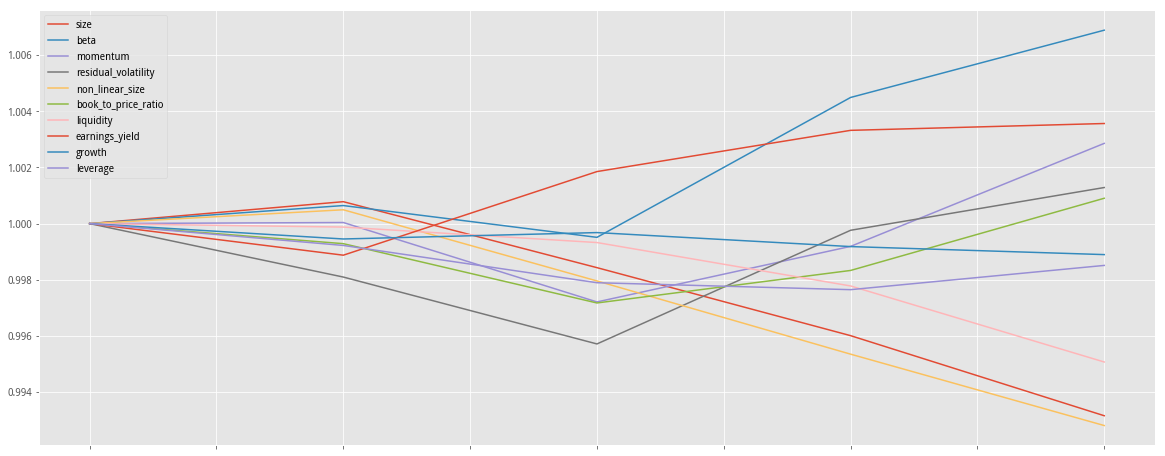

In [29]:
#因子历史资产价值（第一期起初为1）
ones_df=pd.DataFrame(np.ones([1,len(factor_name)]),columns=factor_name,index=[date_list[0]])
temp_df=(factor_f.iloc[:,:10]+1).cumprod()
pd.concat([ones_df,temp_df]).plot(figsize=(20,8))

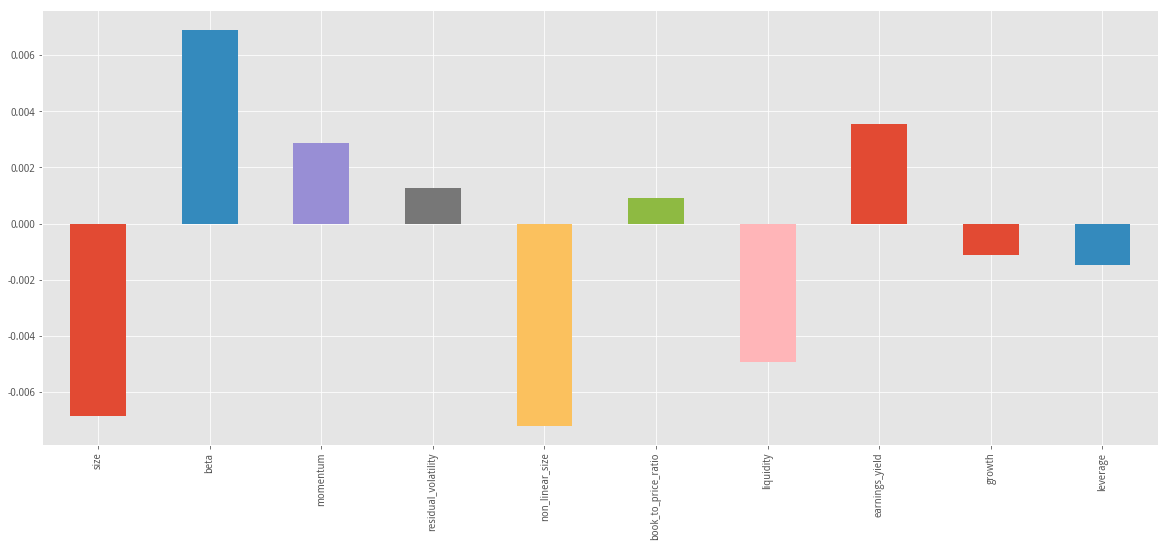

In [30]:
#纯净因子累计收益
((factor_f.iloc[:,:10]+1).cumprod()-1).iloc[-1,:].plot(kind='bar',figsize=(20,8))

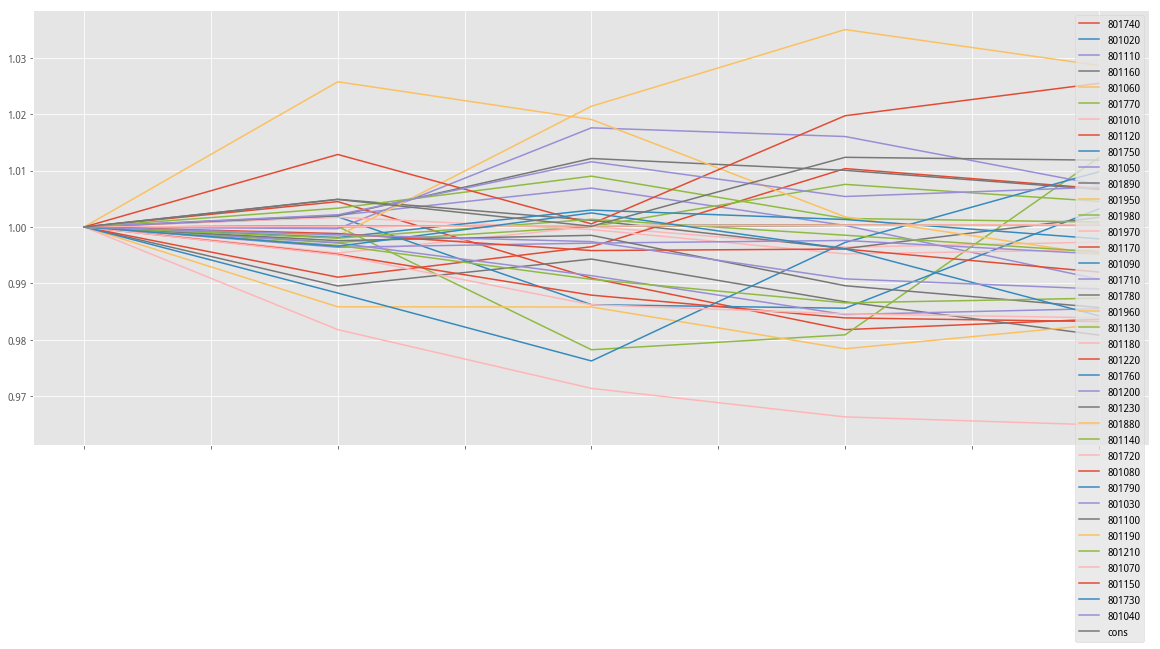

In [31]:
#行业历史资产价值（第一期起初为1）
ones_df=pd.DataFrame(np.ones([1,len(get_industries(name='sw_l1').index)+1])\
                     ,columns=list(get_industries(name='sw_l1').index)+['cons']\
                     ,index=[date_list[0]])
temp_df=(factor_f.iloc[:,10:]+1).cumprod()
pd.concat([ones_df,temp_df]).plot(figsize=(20,8))

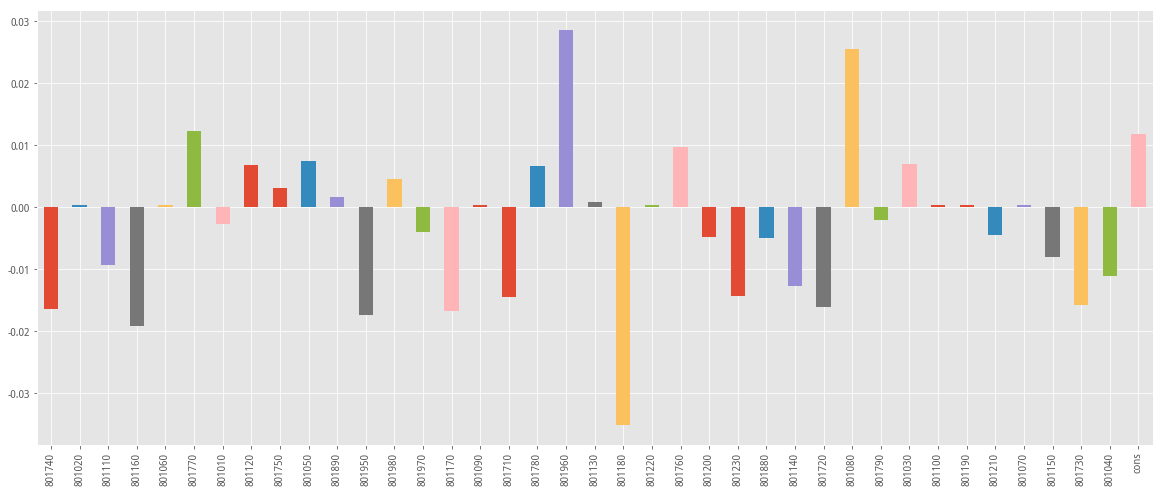

In [32]:
#行业累计收益
(temp_df-1).iloc[-1,:].plot(kind='bar',figsize=(20,8))

### 3.3.2组合收益归因

In [62]:
#中证500选50只股票，进行收益分析
#进行因子值计算
factor_data_50_dict = {}
factor_name = ['size','beta','momentum','residual_volatility','non_linear_size',\
               'book_to_price_ratio','liquidity','earnings_yield','growth',\
               'leverage']
#循环时间列表获取原始因子数据组成dict
for end_date in date_list[1:]:
    end_date=str(end_date)[:10]
    print('正在计算 {} 因子数据......'.format(end_date))
    stocks_list = get_index_stocks(index,date=end_date)
    pool_ = [stocks_list[i] for i in range(len(stocks_list)) if i%10==0]#等间隔选取50只
    stocks_list = pool_
    #计算行业市值权重占比
    hy_df = get_industry_exposure1(pool_,date=end_date).T
    hy_df['cons'] = [1]*len(hy_df)
    x = factor_data_y_dict[end_date].loc[pool_,factor_name]
    df_pct = factor_data_y_dict[end_date].loc[pool_,['pct_']]
    #进行大X拼接
    X_ = pd.concat([x,hy_df,df_pct],axis=1)
    factor_data_50_dict[end_date] = X_
factor_data_50_dict[end_date].head(200)

df = pd.DataFrame(factor_data_50_dict[end_date])

write_file('from_backtest.csv', df.to_csv(), append=False) #写到文件中


正在计算 2023-07-11 因子数据......
正在计算 2023-07-12 因子数据......
正在计算 2023-07-13 因子数据......
正在计算 2023-07-14 因子数据......


143132

In [27]:
#收益率与超额收益率的图表？
factor_fT=factor_f.T
mark = 1
for d in date_list[1:]:
    end_date = str(d)[:10]
    if end_date not in factor_fT.columns:
        pass
    else:
        d1 = factor_data_50_dict[end_date]
        d2 = factor_fT.loc[:,end_date]
        y_df = pd.DataFrame()
        y_df['pct_'] = d1['pct_']
        y_df['p_pct_']= np.dot(d1.iloc[:,:-1],d2)
        if mark == 1:
            y_df_ = y_df
            mark = 0
        else:
            y_df_ = pd.concat([y_df_,y_df],axis=0)
y_df_.head(10)

,pct_,p_pct_
code,,
000009.XSHE,-0.007463,-0.004528
000155.XSHE,0.007597,0.003549
000547.XSHE,0.001001,0.010615
000636.XSHE,0.012282,0.022343
000783.XSHE,-0.003484,-0.005996
000893.XSHE,-0.005117,-0.018413
000970.XSHE,-0.008554,-0.019170
002008.XSHE,0.008445,0.006070
002080.XSHE,0.009246,-0.000128


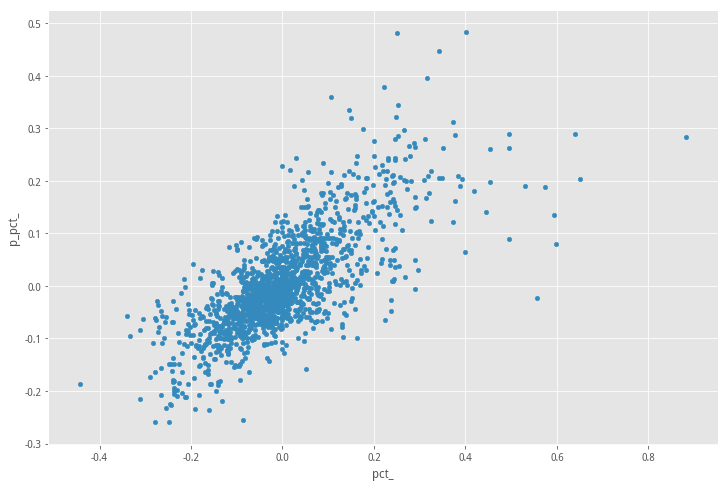

In [515]:
y_df_.plot(x='pct_', y='p_pct_', kind='scatter',figsize=(12,8))

### 3.3.3 以2020-01-02为例,检查因子暴露度百分位

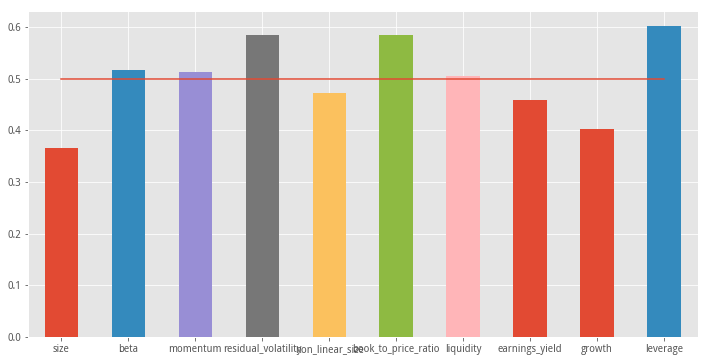

In [516]:
end_date = '2020-02-03'
d3 = factor_data_y_dict[end_date]
d1 = factor_data_50_dict[end_date].dropna(axis=0)
d_mean = d1.mean(axis=0)[:len(factor_name)]#风格因子的均值
d4 = pd.concat([d3.iloc[:,:len(factor_name)].T,d_mean],axis=1)
d4['mid'] = [0.5]*len(d4)
(d4.rank(axis=1)[0]/500).plot(kind='bar',figsize=(12,6))#0号股票各因素在中证500中的排名
d4['mid'].plot()
plt.show()

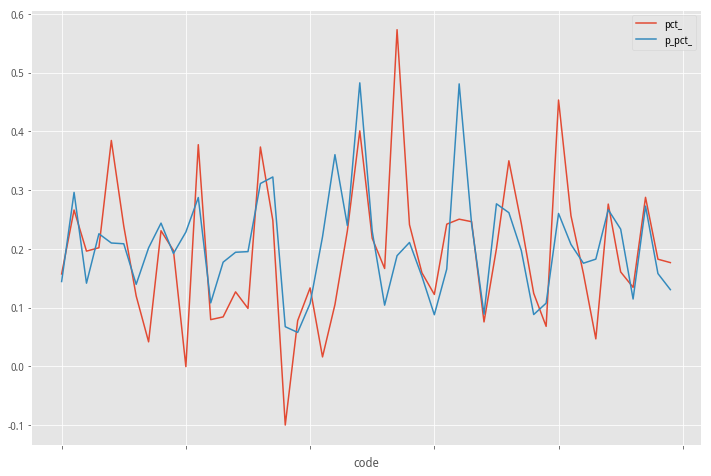

In [517]:
y_df.plot(figsize=(12,8))

## 3.4IC值

In [518]:
# 原来的因子载荷序列中当期股票数据框加入股票下期收益率
factor_data_y_dict_new =  factor_data_y_dict.copy()
factor_data_y_dict_new.pop(str(date_list[-1])[:10])
for idx,timestamp in enumerate(list(date_list[1:-1])):
    print('正在计算'+str(timestamp)[:10])
    t1 = ShiftTradingDay(timestamp,1)
    t2 = ShiftTradingDay(date_list[idx+1],1)
    t3 = ShiftTradingDay(date_list[idx+2],1)
    pool = list(factor_data_y_dict_new[str(timestamp)[:10]].index)
    pool = filter_stock(pool,str(t3)[:10],days=21*3)
    df1 = get_price(pool,end_date=t2,fields=['open'],count = 1)['open']
    df2 = get_price(pool,end_date=t3,fields=['open'],count = 1)['open']
    df3 = pd.concat([df1,df2],axis=0).T #进行合并
    stock_pct_next = df3.iloc[:,1]/df3.iloc[:,0]-1
    factor_data_y_dict_new[str(timestamp)[:10]]['pct_next'] = stock_pct_next
factor_data_y_dict_new[str(date_list[-2])[:10]].head()

正在计算2017-05-02
正在计算2017-06-01
正在计算2017-07-03
正在计算2017-08-01
正在计算2017-09-01
正在计算2017-10-09
正在计算2017-11-01
正在计算2017-12-01
正在计算2018-01-02
正在计算2018-02-01
正在计算2018-03-01
正在计算2018-04-02
正在计算2018-05-02
正在计算2018-06-01
正在计算2018-07-02
正在计算2018-08-01
正在计算2018-09-03
正在计算2018-10-08
正在计算2018-11-01
正在计算2018-12-03
正在计算2019-01-02
正在计算2019-02-01
正在计算2019-03-01
正在计算2019-04-01
正在计算2019-05-06
正在计算2019-06-03
正在计算2019-07-01
正在计算2019-08-01
正在计算2019-09-02
正在计算2019-10-08
正在计算2019-11-01
正在计算2019-12-02
正在计算2020-01-02
正在计算2020-02-03


,size,beta,momentum,residual_volatility,non_linear_size,book_to_price_ratio,liquidity,earnings_yield,growth,leverage,pct_alpha,pct_,pct_next
code,,,,,,,,,,,,,
000006.XSHE,-0.760596,-0.078365,0.241901,-0.771803,0.206789,-0.354303,-0.089794,0.636165,-0.053188,-0.337599,-0.100772,-0.219802,0.157360
000008.XSHE,-0.121358,-0.090629,-0.319934,-0.471681,0.237042,0.292852,0.395294,-0.267893,0.407004,-0.620666,-0.137034,-0.256065,0.210145
000009.XSHE,0.286007,1.188270,-0.113680,0.825208,-0.052631,-0.630917,0.791512,-0.356872,0.757880,1.584451,0.004572,-0.114458,0.345238
000012.XSHE,0.219395,0.178870,0.187158,-0.726831,-0.135559,0.013749,-0.624534,-0.773757,-0.205955,0.002173,-0.137018,-0.256048,0.460705
000021.XSHE,0.434472,0.741838,1.100218,0.692347,-0.323747,-0.303505,0.427659,-0.211707,-0.162373,-0.003288,0.048213,-0.070817,0.598827


In [519]:
factors_ic={}
factors_beta = {}
factors_t = {}

for date_cur,temp_df in factor_data_y_dict_new.items():
    print('正在计算'+date_cur)
    factors_ic_period = []
    factors_beta_period = []
    factors_t_period = []
    temp_df = temp_df.fillna(0)
    for factor in temp_df.columns[:-3]:
        ########### 因子IC ############
        # 计算与最后一列的收益秩相关系数
        ic = st.spearmanr(temp_df[factor],temp_df['pct_next'])[0]
        # 依次存入列表
        factors_ic_period.append(ic)

        ########### 因子收益率,t值,不考虑行业因子###########
        # 每列因子与收益率RLM回归,得到系数,t值
        # 加截距,变成二维
        x=sm.add_constant(temp_df[factor])
        model = sm.RLM(temp_df['pct_'],x).fit()
        factors_beta_period.append(model.params[1])
        factors_t_period.append(model.tvalues[1])
        
    factors_ic[date_cur] = factors_ic_period
    factors_beta[date_cur] = factors_beta_period 
    factors_t[date_cur] = factors_t_period                           

正在计算2017-05-02
正在计算2017-06-01
正在计算2017-07-03
正在计算2017-08-01
正在计算2017-09-01
正在计算2017-10-09
正在计算2017-11-01
正在计算2017-12-01
正在计算2018-01-02
正在计算2018-02-01
正在计算2018-03-01
正在计算2018-04-02
正在计算2018-05-02
正在计算2018-06-01
正在计算2018-07-02
正在计算2018-08-01
正在计算2018-09-03
正在计算2018-10-08
正在计算2018-11-01
正在计算2018-12-03
正在计算2019-01-02
正在计算2019-02-01
正在计算2019-03-01
正在计算2019-04-01
正在计算2019-05-06
正在计算2019-06-03
正在计算2019-07-01
正在计算2019-08-01
正在计算2019-09-02
正在计算2019-10-08
正在计算2019-11-01
正在计算2019-12-02
正在计算2020-01-02
正在计算2020-02-03


In [520]:
factors_ic

{'2017-05-02': [0.04653493555859302,
  -0.17209400570436015,
  0.00874951428701073,
  -0.05801925208109333,
  -0.019968141265807267,
  0.027109885800909405,
  -0.06658227966940683,
  0.05549109726848445,
  -0.006732865847971394,
  -0.0788389919367558],
 '2017-06-01': [0.011676343612199538,
  0.12843421136431066,
  0.06796229045960651,
  0.07681935879877194,
  -0.03297401433017798,
  -0.04864796748738331,
  0.13895843044554546,
  0.029066074741584097,
  0.08325341818726957,
  0.031911463749247804],
 '2017-07-03': [-0.020634165189725925,
  0.04545988894237087,
  -0.006530058563030397,
  -0.17355037801799564,
  -0.06350733721590734,
  0.2230949256833888,
  -0.06618362534954056,
  0.15354258732796086,
  0.024392076175803055,
  0.10951602987158719],
 '2017-08-01': [-0.028548886178268704,
  0.11008023945596361,
  0.033101297412975815,
  0.14757578159846552,
  0.047784909330687776,
  -0.12852379801535269,
  0.12927661297764534,
  -0.027298482750814666,
  0.0041377701810640585,
  -0.0101190561

In [521]:
ic_df = dict_to_df(factors_ic,factor_name,'IC')
beta_df = dict_to_df(factors_beta,factor_name,'beta')
t_df = dict_to_df(factors_t,factor_name,'t')

In [522]:
evaluation(ic_df,beta_df,t_df)

ic表处理完毕!
beta表处理完毕!
t值表处理完毕!


,IC均值,|IC|>0.02,IR,因子收益率均值,因子收益率t检验,p值,|t|均值,|t|大于2的占比,score
liquidity,-0.0429,91.18%,-0.3741,-0.0055,-2.9701,0.0055,2.7732,64.71%,4
size,0.0391,85.29%,0.4031,0.0063,1.8471,0.0737,1.7470,38.24%,3
momentum,0.0286,76.47%,0.2703,0.0047,1.9317,0.0620,2.4539,50.0%,3
residual_volatility,-0.0328,94.12%,-0.2904,-0.0044,-2.3221,0.0265,2.8374,58.82%,3
non_linear_size,-0.0281,76.47%,-0.3557,-0.0052,-2.2886,0.0286,1.2120,26.47%,3
beta,-0.0273,88.24%,-0.2217,-0.0028,-1.3951,0.1723,2.5943,61.76%,2
growth,0.0169,70.59%,0.3265,0.0015,1.9900,0.0549,1.0449,14.71%,2
earnings_yield,0.0145,76.47%,0.1779,0.0028,2.3456,0.0252,1.4751,35.29%,1
book_to_price_ratio,-0.0007,82.35%,-0.0077,0.0005,0.3276,0.7453,1.6036,29.41%,0
leverage,-0.0152,73.53%,-0.2477,-0.0010,-0.9849,0.3318,1.0259,11.76%,0


In [523]:
eval_df = evaluation(ic_df,beta_df,t_df)

ic表处理完毕!
beta表处理完毕!
t值表处理完毕!


In [524]:
def color_negative_red(val):
    color = 'red' if val < 0 else 'black'
    return 'color: %s' % color

eval_df.style.applymap(color_negative_red,subset=['IC均值', '因子收益率均值', 'IR'])

#eval_df.style.applymap(showColor,subset=pd.IndexSlice[1:,1:])#指定表格位置?

,IC均值,|IC|>0.02,IR,因子收益率均值,因子收益率t检验,p值,|t|均值,|t|大于2的占比,score
liquidity,-0.0429,91.18%,-0.3741,-0.0055,-2.9701,0.0055,2.7732,64.71%,4
size,0.0391,85.29%,0.4031,0.0063,1.8471,0.0737,1.747,38.24%,3
momentum,0.0286,76.47%,0.2703,0.0047,1.9317,0.062,2.4539,50.0%,3
residual_volatility,-0.0328,94.12%,-0.2904,-0.0044,-2.3221,0.0265,2.8374,58.82%,3
non_linear_size,-0.0281,76.47%,-0.3557,-0.0052,-2.2886,0.0286,1.212,26.47%,3
beta,-0.0273,88.24%,-0.2217,-0.0028,-1.3951,0.1723,2.5943,61.76%,2
growth,0.0169,70.59%,0.3265,0.0015,1.99,0.0549,1.0449,14.71%,2
earnings_yield,0.0145,76.47%,0.1779,0.0028,2.3456,0.0252,1.4751,35.29%,1
book_to_price_ratio,-0.0007,82.35%,-0.0077,0.0005,0.3276,0.7453,1.6036,29.41%,0
leverage,-0.0152,73.53%,-0.2477,-0.001,-0.9849,0.3318,1.0259,11.76%,0


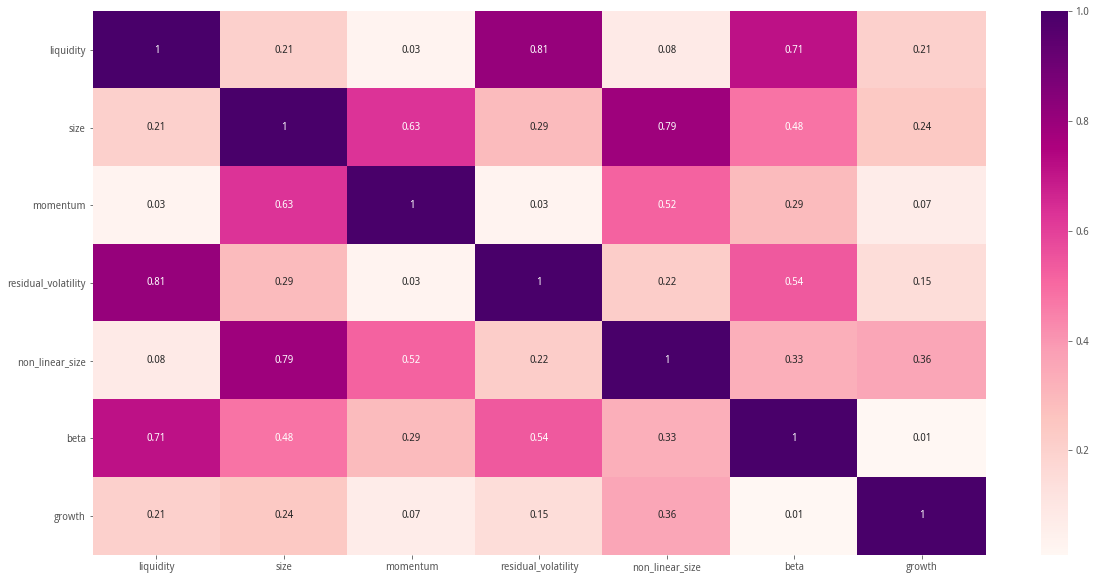

In [525]:
corr = plot_heat(ic_df,eval_df)

In [526]:
corr

,liquidity,size,momentum,residual_volatility,non_linear_size,beta,growth
liquidity,1.00,-0.21,-0.03,0.81,0.08,0.71,0.21
size,-0.21,1.00,0.63,-0.29,-0.79,-0.48,0.24
momentum,-0.03,0.63,1.00,-0.03,-0.52,-0.29,-0.07
residual_volatility,0.81,-0.29,-0.03,1.00,0.22,0.54,0.15
non_linear_size,0.08,-0.79,-0.52,0.22,1.00,0.33,-0.36
beta,0.71,-0.48,-0.29,0.54,0.33,1.00,-0.01
growth,0.21,0.24,-0.07,0.15,-0.36,-0.01,1.00


# 4 分层回测


分组回测

①每个交易日取出股票池中股票的因子值，按从小到大进行排序，将排序后的股票池等分成N个股票组合。(本文采用5等分股票池）

②等额买入每个等份的股票组合，月底重复①②两步并重新调仓，最后计算平均收益。(本文默认按月调仓）

③在总的时间区间上，每个调仓周期结束后进行一个复利的计算，最后将每组股票的累计收益绘制出来进行对比。

In [556]:
#设置用于分组检查的因子值
factor_test = 'momentum'
pool_dict = {}
groups = 5
return_dict={}
for date_cur,temp_df in factor_data_y_dict_new.items():
    group_split = pd.qcut(temp_df[factor_test],5,labels = \
                          ['l1','l2','l3','l4','l5'])#将股票池分为l1-l5五类
    group1 = group_split[group_split=='l1'].index
    group2 = group_split[group_split=='l2'].index
    group3 = group_split[group_split=='l3'].index
    group4 = group_split[group_split=='l4'].index
    group5 = group_split[group_split=='l5'].index
    pool_dict[date_cur] = [group1,group2,group3,group4,group5]

In [557]:
return_df = pd.DataFrame()
for idx,datetimeindex in enumerate(date_list[1:-1]):
    datetimeindex = str(datetimeindex)[:10]
    
    for idx_g,group in enumerate(pool_dict[datetimeindex]):
        group = list(group)
        price1 = get_price(group,end_date=datetimeindex,\
                           fields=['open'],count = 1)['open']
        price2 = get_price(group,end_date=list(date_list)[idx+2],\
                           fields=['open'],count = 1)['open']
        price3 = pd.concat([price1,price2],axis=0).T #进行合并
        ret = (price3.iloc[:,1]/price3.iloc[:,0] -1).mean()#每期收益率
        return_df.loc[datetimeindex,idx_g] = ret     
return_df.columns = ['group1','group2','group3','group4','group5']
return_df1=(return_df+1).cumprod()
return_df1

,group1,group2,group3,group4,group5
2017-05-02,0.940116,0.939313,0.931706,0.936532,0.931416
2017-06-01,0.987949,0.976831,0.985570,0.990154,0.995013
2017-07-03,1.003200,0.998490,1.021614,1.012132,1.012714
2017-08-01,1.034474,1.024866,1.045270,1.039915,1.054551
2017-09-01,1.071223,1.057957,1.066480,1.073212,1.087934
2017-10-09,1.038215,1.030709,1.038277,1.050854,1.065023
2017-11-01,0.973501,0.983598,0.985443,1.018223,1.007661
2017-12-01,0.959547,0.981567,0.972947,1.019442,1.009955
2018-01-02,0.933450,0.970785,0.971245,1.001857,0.981675
2018-02-01,0.897191,0.921293,0.930337,0.962522,0.972891


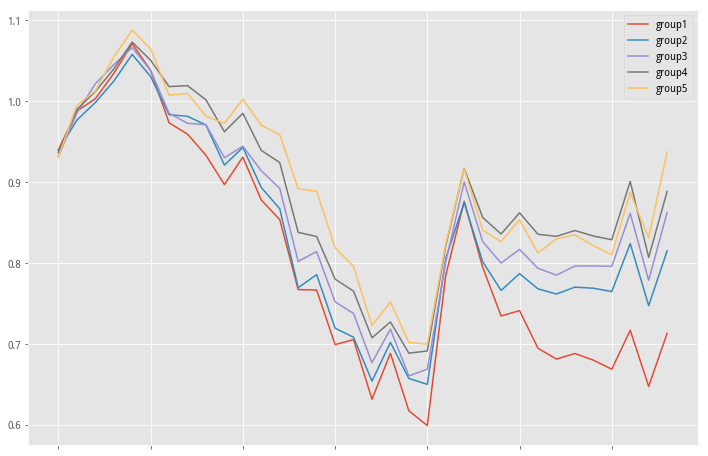

In [558]:
return_df1.plot(figsize=(12,8))